In [1]:
import numpy as np
import pandas as pd 
import shutil
import random
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import time
import numpy as np
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
!pip install timm
import timm
import argparse
import json
from collections import defaultdict
from datetime import datetime
import copy
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc, roc_auc_score)

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [2]:
raw_data_dir = "/kaggle/input/sickle-cell-disease-dataset"

def count_images_nested(raw_dir):
    counts = {}
    total_images = 0
    
    for category in os.listdir(raw_dir):  # negative, positive
        category_path = os.path.join(raw_dir, category)
        if not os.path.isdir(category_path):
            continue
        
        # For subfolders like clear, labelled, unlabelled
        for subfolder in os.listdir(category_path):
            sub_path = os.path.join(category_path, subfolder)
            if not os.path.isdir(sub_path):
                continue
            
            num_images = len([
                f for f in os.listdir(sub_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))
            ])
            
            key_name = f"{category}/{subfolder}"
            counts[key_name] = num_images
            total_images += num_images
    
    return counts, total_images


# Run the function
raw_counts, total_images = count_images_nested(raw_data_dir)

# Print results
print("Raw dataset image counts per class:")
for cls, num in raw_counts.items():
    print(f"{cls}: {num} images")

print(f"\nTotal images: {total_images}")

Raw dataset image counts per class:
Negative/Clear: 147 images
Positive/Unlabelled: 422 images
Positive/Labelled: 422 images

Total images: 991


In [3]:
raw_data_dir = "/kaggle/input/sickle-cell-disease-dataset"
output_dir = "/kaggle/working/dataset_split"

In [3]:
train_ratio, val_ratio, test_ratio = 0.7, 0.15, 0.15

def split_dataset(raw_dir, output_dir, train_ratio, val_ratio, test_ratio):
    os.makedirs(output_dir, exist_ok=True)

    # Explicitly define your class mappings
    data_map = {
        "negative": os.path.join(raw_dir, "Negative", "Clear"),
        "positive": os.path.join(raw_dir, "Positive", "Unlabelled")
    }

    for class_name, src_dir in data_map.items():
        if not os.path.exists(src_dir):
            print(f" Skipping {class_name}, source not found: {src_dir}")
            continue

        # Collect image files
        images = [os.path.join(src_dir, f) for f in os.listdir(src_dir)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        random.shuffle(images)

        n_total = len(images)
        n_train = int(n_total * train_ratio)
        n_val = int(n_total * val_ratio)

        # Split
        splits = {
            "train": images[:n_train],
            "val": images[n_train:n_train + n_val],
            "test": images[n_train + n_val:]
        }

        # Copy images into lowercase folders
        for split, split_imgs in splits.items():
            split_dir = os.path.join(output_dir, split, class_name)
            os.makedirs(split_dir, exist_ok=True)
            for img_path in split_imgs:
                shutil.copy2(img_path, os.path.join(split_dir, os.path.basename(img_path)))

        print(f" {class_name.capitalize()} → Split complete ({n_total} images)")

    print("\n Dataset splitting done successfully!")

# Run
split_dataset(raw_data_dir, output_dir, train_ratio, val_ratio, test_ratio)

 Negative → Split complete (147 images)
 Positive → Split complete (422 images)

 Dataset splitting done successfully!


In [4]:
def count_images(root_dir):
    summary = {}
    for split in ["train", "val", "test"]:
        split_dir = os.path.join(root_dir, split)
        summary[split] = {}
        for class_name in os.listdir(split_dir):
            class_path = os.path.join(split_dir, class_name)
            if not os.path.isdir(class_path):
                continue
            count = len([f for f in os.listdir(class_path)
                         if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            summary[split][class_name] = count
    return summary

# Run and print counts
counts = count_images(output_dir)
for split, classes in counts.items():
    print(f"\n{split.upper()}:")
    for cls, cnt in classes.items():
        print(f"  {cls}: {cnt} images")


TRAIN:
  negative: 102 images
  positive: 295 images

VAL:
  negative: 22 images
  positive: 63 images

TEST:
  negative: 23 images
  positive: 64 images


In [5]:
# ------------- Config / hyperparams -------------
DATA_DIR = "dataset_split"   # expects dataset_split/train/<class> etc
CHECKPOINT_DIR = "checkpoints"
OUTPUT_DIR = "outputs"
BATCH_SIZE = 32
IMG_SIZE = 224
NUM_WORKERS = 4
LR = 1e-4
WEIGHT_DECAY = 1e-4
EPOCHS = 100
EARLY_STOPPING_PATIENCE = 10
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# create dirs
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [6]:
# ------------- Utils -------------
def makedirs(path):
    os.makedirs(path, exist_ok=True)

def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

In [7]:
# ------------- Dataloader -------------
def get_dataloaders(data_dir, img_size=IMG_SIZE, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS):
    train_transforms = transforms.Compose([
        transforms.RandomResizedCrop(img_size),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.2,0.2,0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])
    val_test_transforms = transforms.Compose([
        transforms.Resize(int(img_size*1.1)),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])

    train_ds = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transforms)
    val_ds   = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=val_test_transforms)
    test_ds  = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=val_test_transforms)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    class_names = train_ds.classes
    return train_loader, val_loader, test_loader, class_names

In [8]:
# ------------- Attention (SE block) -------------
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        w = self.fc(x).view(b, c, 1, 1)
        return x * w

In [26]:
def add_se_to_model(model, target_layer_name=None):
    """
    Attach SE block to CNN backbones:
    - ResNet
    - MobileNetV2
    - VGG
    - DenseNet
    - EfficientNetB0 (torchvision & timm)
    - InceptionV3
    """
    # -------- RESNET (ResNet50 etc) -----------
    if hasattr(model, "layer4"):
        orig = model.layer4
        last_conv_channels = None
        for m in reversed(list(orig.modules())):
            if isinstance(m, nn.Conv2d):
                last_conv_channels = m.out_channels
                break
        if last_conv_channels is not None:
            se = SEBlock(last_conv_channels)
            model.layer4 = nn.Sequential(orig, se)
        return model

    # -------- MOBILENETV2 ----------
    if hasattr(model, "features") and "MobileNetV2" in str(type(model)):
        last_conv_channels = None
        for m in reversed(list(model.features.modules())):
            if isinstance(m, nn.Conv2d):
                last_conv_channels = m.out_channels
                break
        if last_conv_channels:
            model.features = nn.Sequential(model.features, SEBlock(last_conv_channels))
        return model

    # -------- VGG ----------
    if "VGG" in str(type(model)):
        last_conv_channels = None
        for m in reversed(list(model.features.modules())):
            if isinstance(m, nn.Conv2d):
                last_conv_channels = m.out_channels
                break
        if last_conv_channels:
            model.features = nn.Sequential(model.features, SEBlock(last_conv_channels))
        return model

   # ---- DENSENET121 ----
    if "densenet121" in str(type(model)):
        model = models.densenet121(pretrained=pretrained)
    
        #  Correct classifier (1024 → num_classes)
        model.classifier = nn.Linear(1024, num_classes)
    
        # Add SE after features
        if use_se:
            last_conv = None
            for m in reversed(list(model.features.modules())):
                if isinstance(m, nn.Conv2d):
                    last_conv = m.out_channels
                    break
            
            model.features = nn.Sequential(
                model.features,
                SEBlock(last_conv)
            )
    
        return model

    # -------- EFFICIENTNET (torchvision) ----------
    if "EfficientNet" in str(type(model)):  # covers B0 & others
        # last conv layer is in features[-1]
        last_conv = None
        for m in reversed(list(model.features.modules())):
            if isinstance(m, nn.Conv2d):
                last_conv = m.out_channels
                break
        if last_conv:
            model.features = nn.Sequential(model.features, SEBlock(last_conv))
        return model

    # -------- EFFICIENTNET / SWIN via TIMM ----------
    if hasattr(model, "conv_head") and hasattr(model, "blocks"):
        if isinstance(model.conv_head, nn.Conv2d):
            out_ch = model.conv_head.out_channels
            model.se_post = SEBlock(out_ch)

            # Monkey-patch forward
            old_forward = model.forward

            def forward_with_se(x):
                x = old_forward(x)
                x = model.se_post(x)
                return x

            model.forward = forward_with_se
        return model

    return model  # fallback

In [24]:
def build_model(name, num_classes, pretrained=True, use_se=True):
    name = name.lower()

    # ------------------ RESNET18 ------------------
    if name == "resnet18":
        model = models.resnet18(pretrained=pretrained)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        if use_se:
            model = add_se_to_model(model)
        return model

    # ------------------ RESNET50 ------------------
    if name == "resnet50":
        model = models.resnet50(pretrained=pretrained)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        if use_se:
            model = add_se_to_model(model)
        return model

    # ------------------ VGG16 ------------------
    if name == "vgg16":
        model = models.vgg16(pretrained=pretrained)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
        if use_se:
            model = add_se_to_model(model)
        return model

    # ------------------ MOBILENETV2 ------------------
    if name in ["mobilenet_v2", "mobilenetv2"]:
        model = models.mobilenet_v2(pretrained=pretrained)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
        if use_se:
            model = add_se_to_model(model)
        return model

    # ------------------ DENSENET121 ------------------
    if name == "densenet121":
        model = models.densenet121(pretrained=pretrained)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
        if use_se:
            model = add_se_to_model(model)
        return model

    # ------------------ EFFICIENTNET-B0 (Torchvision) ------------------
    if name in ["efficientnet_b0", "efficientnet"]:
        try:
            model = models.efficientnet_b0(pretrained=pretrained)
            model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
            if use_se:
                model = add_se_to_model(model)
            return model
        except:
            # Fallback: timm
            model = timm.create_model("efficientnet_b0", pretrained=pretrained, num_classes=num_classes)
            return model

    # ------------------ SWIN TRANSFORMER ------------------
    if name in ["swin_tiny", "swin"]:
        model = timm.create_model("swin_tiny_patch4_window7_224", pretrained=pretrained, num_classes=num_classes)
        return model

    # ------------------ UNKNOWN ------------------
    raise ValueError(f"Unknown model {name}")

In [11]:

# ------------- Training / evaluation helpers -------------
def save_checkpoint(state, filename):
    torch.save(state, filename)

class EarlyStopping:
    def __init__(self, patience=EARLY_STOPPING_PATIENCE, minimize=False):
        self.patience = patience
        self.counter = 0
        self.best = None
        self.minimize = minimize

    def step(self, metric):
        if self.best is None:
            self.best = metric
            return False
        improved = (metric < self.best) if self.minimize else (metric > self.best)
        if improved:
            self.best = metric
            self.counter = 0
            return False
        else:
            self.counter += 1
            return self.counter >= self.patience

def compute_metrics_all(y_true, y_pred, y_score, average="macro"):
    # y_score: N x C probability scores for ROC/AUC
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average=average, zero_division=0)
    rec = recall_score(y_true, y_pred, average=average, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=average, zero_division=0)

    # multiclass ROC AUC (one-vs-rest)
    try:
        roc_auc = roc_auc_score(
            np.eye(len(np.unique(y_true)))[y_true],   # one-hot true
            y_score, average="macro", multi_class="ovr"
        )
    except Exception:
        roc_auc = None

    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "roc_auc": roc_auc}

def evaluate(model, loader, device, num_classes):
    model.eval()
    ys, ys_pred, ys_prob = [], [], []
    soft = nn.Softmax(dim=1)
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            probs = soft(logits).cpu().numpy()
            preds = np.argmax(probs, axis=1)
            ys.extend(yb.cpu().numpy().tolist())
            ys_pred.extend(preds.tolist())
            ys_prob.extend(probs.tolist())
    ys = np.array(ys)
    ys_pred = np.array(ys_pred)
    ys_prob = np.array(ys_prob)
    metrics = compute_metrics_all(ys, ys_pred, ys_prob)
    cm = confusion_matrix(ys, ys_pred)
    return metrics, cm, ys, ys_pred, ys_prob

In [12]:
# ------------- Training loop -------------
def train_and_evaluate(model_name, dataloaders, class_names, device, output_root, epochs=EPOCHS,
                       lr=LR, weight_decay=WEIGHT_DECAY, resume_checkpoint=None):
    train_loader, val_loader, test_loader = dataloaders
    num_classes = len(class_names)
    model = build_model(model_name, num_classes=num_classes, pretrained=True, use_se=True)
    model = model.to(device)

    # optimizer & scheduler
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)

    start_epoch = 0
    history = defaultdict(list)
    best_val_f1 = -1.0

    checkpoint_path = os.path.join(CHECKPOINT_DIR, f"{model_name}_best.pth")
    resume_path = resume_checkpoint or None
    if resume_path and os.path.exists(resume_path):
        print(f"Resuming from {resume_path}")
        cp = torch.load(resume_path, map_location=device, weights_only=False)
        model.load_state_dict(cp['model_state'])
        optimizer.load_state_dict(cp['opt_state'])
        start_epoch = cp.get('epoch', 0) + 1
        history = cp.get('history', defaultdict(list))
        best_val_f1 = cp.get('best_val_f1', best_val_f1)

    early_stopper = EarlyStopping(patience=EARLY_STOPPING_PATIENCE)

    soft = nn.Softmax(dim=1)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(start_epoch, epochs):
        print(f"\n=== {model_name} Epoch {epoch+1}/{epochs} ===")
        # train
        model.train()
        running_loss = 0.0
        all_preds = []
        all_targets = []
        for xb, yb in train_loader:
            xb = xb.to(device); yb = yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds.tolist())
            all_targets.extend(yb.cpu().numpy().tolist())

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = accuracy_score(all_targets, all_preds)
        epoch_prec = precision_score(all_targets, all_preds, average="macro", zero_division=0)
        epoch_rec = recall_score(all_targets, all_preds, average="macro", zero_division=0)
        epoch_f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)

        print(f"Train loss: {epoch_loss:.4f} acc: {epoch_acc:.4f} f1: {epoch_f1:.4f}")
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)
        history['train_f1'].append(epoch_f1)

        # val
        val_metrics, val_cm, _, _, _ = evaluate(model, val_loader, device, num_classes)
        print(f"Val metrics: acc {val_metrics['accuracy']:.4f} f1 {val_metrics['f1']:.4f} roc_auc {val_metrics['roc_auc']}")
        history['val_acc'].append(val_metrics['accuracy'])
        history['val_f1'].append(val_metrics['f1'])
        history['val_metrics'].append(val_metrics)

        # scheduler step on val f1
        if val_metrics['f1'] is not None:
            scheduler.step(val_metrics['f1'])

        # checkpoint
        is_best = val_metrics['f1'] is not None and val_metrics['f1'] > best_val_f1
        if is_best:
            best_val_f1 = val_metrics['f1']
            save_checkpoint({
                'epoch': epoch,
                'model_state': model.state_dict(),
                'opt_state': optimizer.state_dict(),
                'best_val_f1': best_val_f1,
                'history': history,
                'class_names': class_names
            }, checkpoint_path)
            print(f"Saved best checkpoint to {checkpoint_path}")

        # # periodic checkpoint (so we can resume)
        # periodic_path = os.path.join(CHECKPOINT_DIR, f"{model_name}_epoch_{epoch}.pth")
        # save_checkpoint({
        #     'epoch': epoch,
        #     'model_state': model.state_dict(),
        #     'opt_state': optimizer.state_dict(),
        #     'best_val_f1': best_val_f1,
        #     'history': history,
        #     'class_names': class_names
        # }, periodic_path)

        # early stopping
        stop = early_stopper.step(val_metrics['f1'] if val_metrics['f1'] is not None else 0)
        if stop:
            print("Early stopping triggered.")
            break

    # After training -> final eval on train/val/test and save results
    print("Evaluating final models on train/val/test...")
    metrics_train, cm_train, y_train, y_train_pred, y_train_prob = evaluate(model, train_loader, device, num_classes)
    metrics_val, cm_val, y_val, y_val_pred, y_val_prob = evaluate(model, val_loader, device, num_classes)
    metrics_test, cm_test, y_test, y_test_pred, y_test_prob = evaluate(model, test_loader, device, num_classes)

    # save model final
    final_path = os.path.join(OUTPUT_DIR, f"{model_name}_final.pth")
    torch.save({'model_state': model.state_dict(),
                'class_names': class_names}, final_path)
    print(f"Saved final model to {final_path}")

    # save metrics and confusion matrices and histories
    timeid = datetime.now().strftime("%Y%m%d_%H%M%S")
    out = {
        "model_name": model_name,
        "history": history,
        "metrics_train": metrics_train,
        "metrics_val": metrics_val,
        "metrics_test": metrics_test,
        "cm_train": cm_train.tolist() if isinstance(cm_train, np.ndarray) else cm_train,
        "cm_val": cm_val.tolist(),
        "cm_test": cm_test.tolist(),
        "class_names": class_names
    }
    save_json(out, os.path.join(OUTPUT_DIR, f"{model_name}_results_{timeid}.json"))

    # # Plot ROC (one-vs-rest)
    # try:
    #     plot_roc_curves(y_test, y_test_prob, class_names, os.path.join(OUTPUT_DIR, f"{model_name}_roc_{timeid}.png"))
    # except Exception as e:
    #     print("Failed to plot ROC:", e)

    # # Save a few Grad-CAM examples from test set
    # try:
    #     save_some_gradcam_examples(model, test_loader, class_names, device, os.path.join(OUTPUT_DIR, f"{model_name}_gradcam"))
    # except Exception as e:
    #     print("Failed to run Grad-CAM:", e)

    print("Done training and evaluation for", model_name)
    return out

In [13]:
def main(model_name="resnet18", resume=None, epochs=EPOCHS, batch_size=BATCH_SIZE):
    global BATCH_SIZE
    BATCH_SIZE = batch_size

    dataloaders = get_dataloaders(DATA_DIR, img_size=IMG_SIZE, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)
    train_loader, val_loader, test_loader, class_names = dataloaders

    if model_name == "all":
        models_to_run = [
            "resnet18",
            "resnet50",
            "vgg16",
            "mobilenet_v2",
            "efficientnet_b0",
            "swin_tiny",
            "densenet121",
            "inception_v3"
        ]
    else:
        models_to_run = [model_name]

    for mname in models_to_run:
        print(f"\n*** Running: {mname} ***")
        out = train_and_evaluate(
            mname,
            (train_loader, val_loader, test_loader),
            class_names,
            DEVICE,
            OUTPUT_DIR,
            epochs=epochs,
            resume_checkpoint=resume
        )

In [14]:
main("resnet50")


*** Running: resnet50 ***


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



=== resnet50 Epoch 1/100 ===
Train loss: 0.4248 acc: 0.8438 f1: 0.7981
Val metrics: acc 0.9059 f1 0.8839 roc_auc 0.9191919191919192
Saved best checkpoint to checkpoints/resnet50_best.pth

=== resnet50 Epoch 2/100 ===
Train loss: 0.2422 acc: 0.9018 f1: 0.8684
Val metrics: acc 0.9059 f1 0.8808 roc_auc 0.9264069264069263

=== resnet50 Epoch 3/100 ===
Train loss: 0.2364 acc: 0.9144 f1: 0.8919
Val metrics: acc 0.9176 f1 0.8942 roc_auc 0.9314574314574315
Saved best checkpoint to checkpoints/resnet50_best.pth

=== resnet50 Epoch 4/100 ===
Train loss: 0.2045 acc: 0.9194 f1: 0.8923
Val metrics: acc 0.8706 f1 0.8232 roc_auc 0.9357864357864358

=== resnet50 Epoch 5/100 ===
Train loss: 0.2137 acc: 0.9194 f1: 0.8964
Val metrics: acc 0.8824 f1 0.8365 roc_auc 0.9235209235209234

=== resnet50 Epoch 6/100 ===
Train loss: 0.1809 acc: 0.9320 f1: 0.9089
Val metrics: acc 0.9412 f1 0.9244 roc_auc 0.9292929292929293
Saved best checkpoint to checkpoints/resnet50_best.pth

=== resnet50 Epoch 7/100 ===
Train l

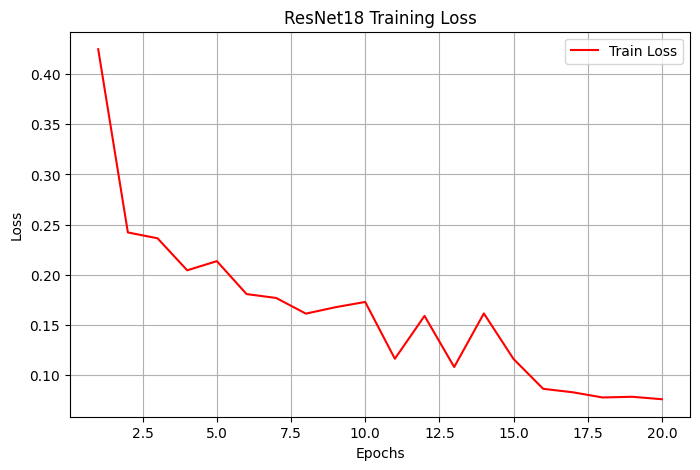

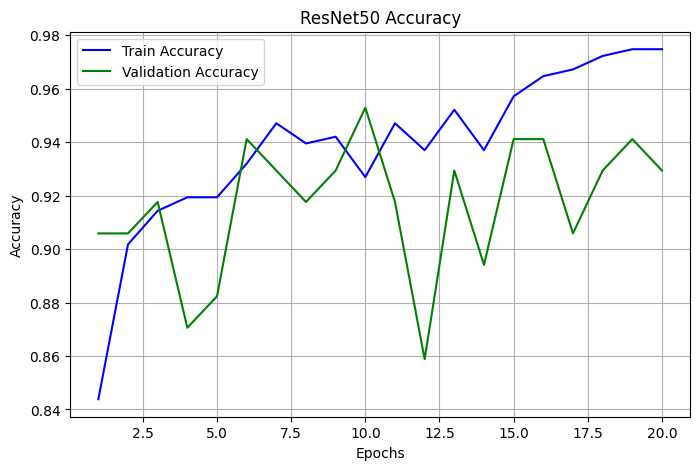

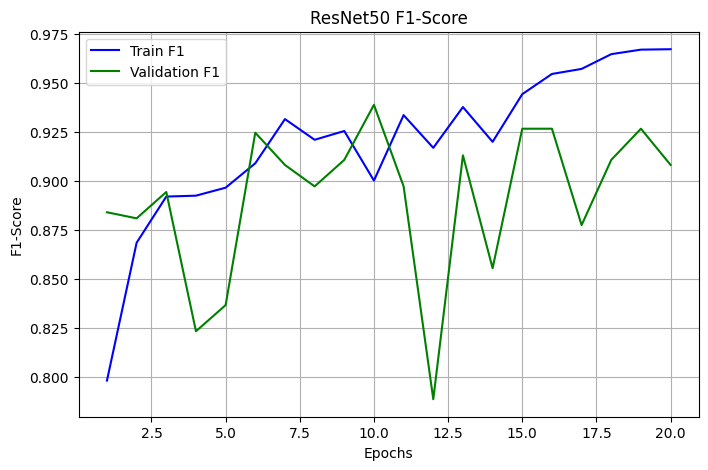

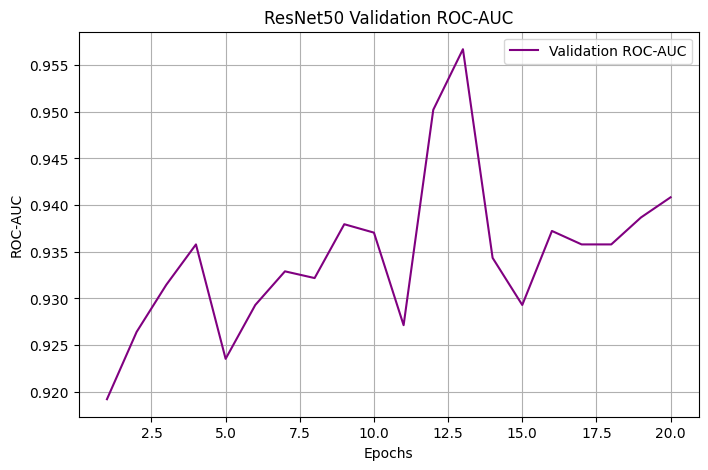

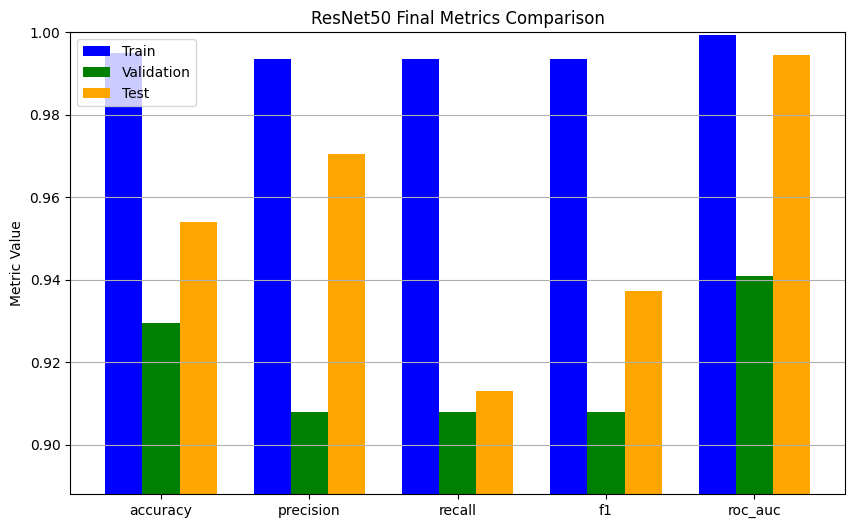

In [16]:
import json
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Load JSON file with outputs
# -----------------------------
with open('/kaggle/working/outputs/resnet50_results_20251107_170138.json', 'r') as f:
    data = json.load(f)

history = data['history']

# Extract metrics
train_loss = history['train_loss']
train_acc = history['train_acc']
train_f1 = history['train_f1']

val_acc = history['val_acc']
val_f1 = history['val_f1']
val_roc_auc = [m['roc_auc'] for m in history['val_metrics']]

epochs = list(range(1, len(train_loss) + 1))

# -----------------------------
# Plot Loss
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, label='Train Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('ResNet18 Training Loss')
plt.grid(True)
plt.legend()
plt.show()
# -----------------------------
# Plot Accuracy
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(epochs, train_acc, label='Train Accuracy', color='blue')
plt.plot(epochs, val_acc, label='Validation Accuracy', color='green')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('ResNet50 Accuracy')
plt.grid(True)
plt.legend()
plt.show()

# -----------------------------
# Plot F1-Score
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(epochs, train_f1, label='Train F1', color='blue')
plt.plot(epochs, val_f1, label='Validation F1', color='green')
plt.xlabel('Epochs')
plt.ylabel('F1-Score')
plt.title('ResNet50 F1-Score')
plt.grid(True)
plt.legend()
plt.show()

# -----------------------------
# Plot ROC-AUC
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(epochs, val_roc_auc, label='Validation ROC-AUC', color='purple')
plt.xlabel('Epochs')
plt.ylabel('ROC-AUC')
plt.title('ResNet50 Validation ROC-AUC')
plt.grid(True)
plt.legend()
plt.show()
# -----------------------------
# Final Metrics Comparison (Train, Validation, Test)
# -----------------------------
metrics_train = data['metrics_train']
metrics_val = data['metrics_val']
metrics_test = data['metrics_test']

metric_names = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

train_values = [metrics_train[m] for m in metric_names]
val_values = [metrics_val[m] for m in metric_names]
test_values = [metrics_test[m] for m in metric_names]

x = np.arange(len(metric_names))  # the label locations
width = 0.25  # width of the bars

plt.figure(figsize=(10,6))
plt.bar(x - width, train_values, width, label='Train', color='blue')
plt.bar(x, val_values, width, label='Validation', color='green')
plt.bar(x + width, test_values, width, label='Test', color='orange')

plt.xticks(x, metric_names)
min_val = min(train_values + val_values + test_values)
plt.ylim(min_val - 0.02, 1.0)
plt.ylabel('Metric Value')
plt.title('ResNet50 Final Metrics Comparison')
plt.grid(axis='y')
plt.legend()
plt.show()

In [17]:
main("vgg16")


*** Running: vgg16 ***


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:02<00:00, 224MB/s]  



=== vgg16 Epoch 1/100 ===
Train loss: 0.5122 acc: 0.7657 f1: 0.6723
Val metrics: acc 0.8235 f1 0.7180 roc_auc 0.8773448773448773
Saved best checkpoint to checkpoints/vgg16_best.pth

=== vgg16 Epoch 2/100 ===
Train loss: 0.3044 acc: 0.8791 f1: 0.8248
Val metrics: acc 0.8353 f1 0.8100 roc_auc 0.8665223665223666
Saved best checkpoint to checkpoints/vgg16_best.pth

=== vgg16 Epoch 3/100 ===
Train loss: 0.3112 acc: 0.8766 f1: 0.8455
Val metrics: acc 0.8706 f1 0.8288 roc_auc 0.8888888888888888
Saved best checkpoint to checkpoints/vgg16_best.pth

=== vgg16 Epoch 4/100 ===
Train loss: 0.3325 acc: 0.8690 f1: 0.8346
Val metrics: acc 0.8706 f1 0.8383 roc_auc 0.8903318903318903
Saved best checkpoint to checkpoints/vgg16_best.pth

=== vgg16 Epoch 5/100 ===
Train loss: 0.2424 acc: 0.9144 f1: 0.8879
Val metrics: acc 0.8824 f1 0.8548 roc_auc 0.8852813852813852
Saved best checkpoint to checkpoints/vgg16_best.pth

=== vgg16 Epoch 6/100 ===
Train loss: 0.3307 acc: 0.8690 f1: 0.8251
Val metrics: acc 0.81

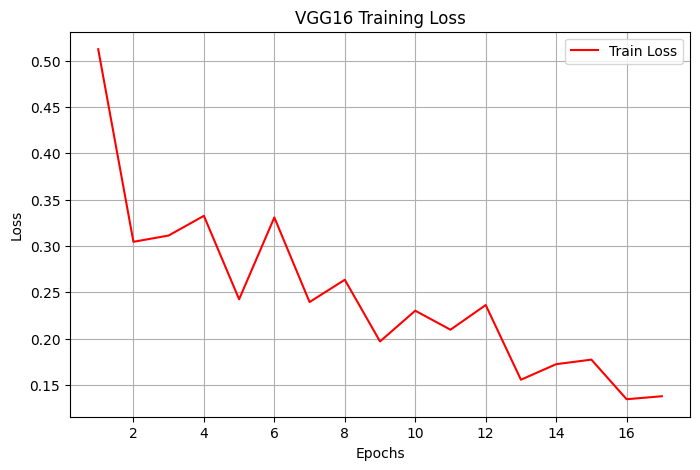

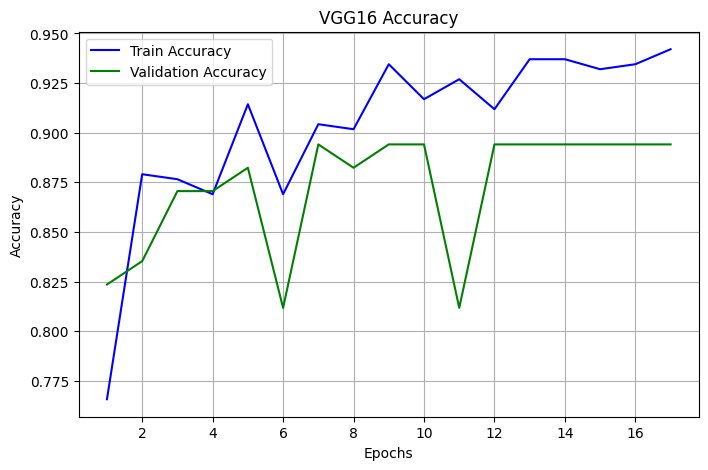

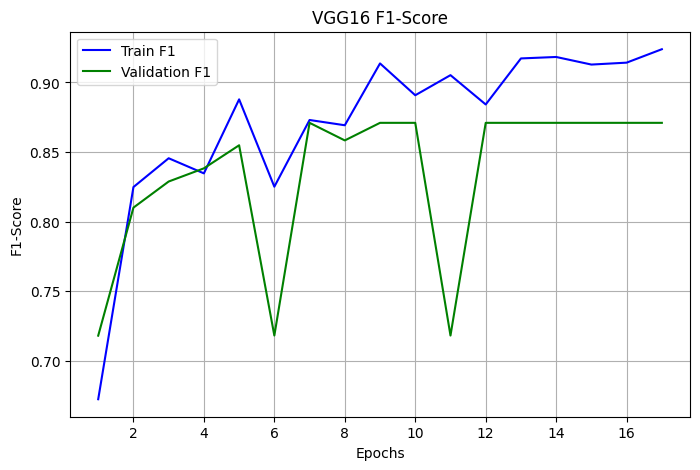

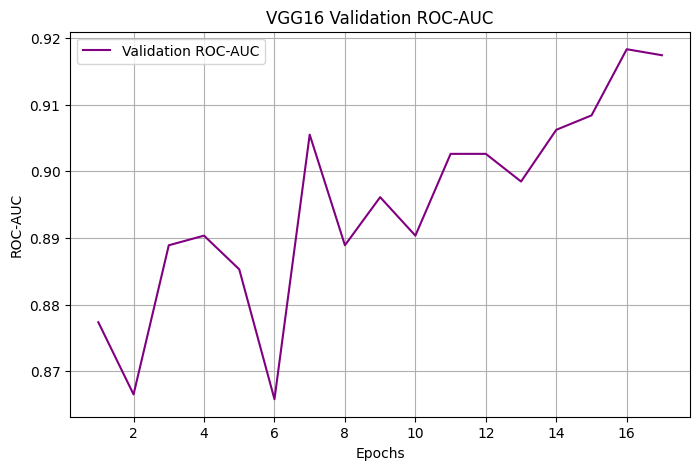

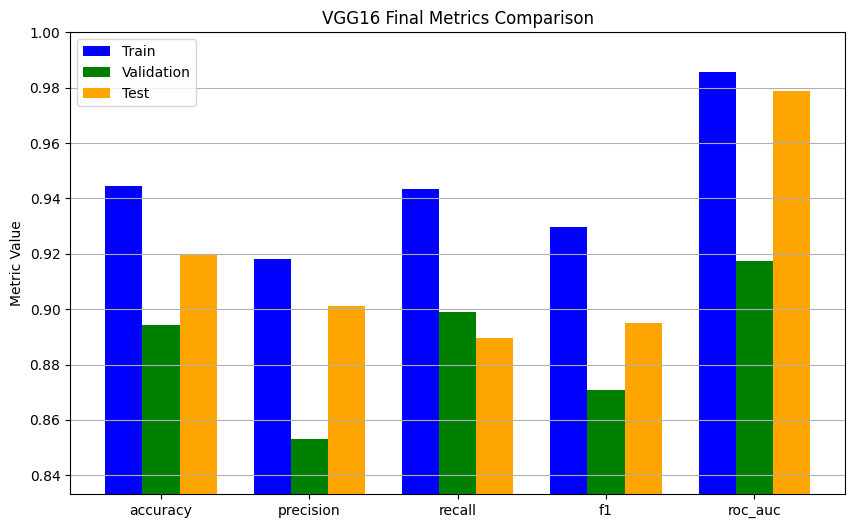

In [18]:
# -----------------------------
# Load JSON file with outputs
# -----------------------------
with open('/kaggle/working/outputs/vgg16_results_20251107_171703.json', 'r') as f:
    data = json.load(f)

history = data['history']

# Extract metrics
train_loss = history['train_loss']
train_acc = history['train_acc']
train_f1 = history['train_f1']

val_acc = history['val_acc']
val_f1 = history['val_f1']
val_roc_auc = [m['roc_auc'] for m in history['val_metrics']]

epochs = list(range(1, len(train_loss) + 1))

# -----------------------------
# Plot Loss
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, label='Train Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('VGG16 Training Loss')
plt.grid(True)
plt.legend()
plt.show()
# -----------------------------
# Plot Accuracy
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(epochs, train_acc, label='Train Accuracy', color='blue')
plt.plot(epochs, val_acc, label='Validation Accuracy', color='green')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('VGG16 Accuracy')
plt.grid(True)
plt.legend()
plt.show()

# -----------------------------
# Plot F1-Score
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(epochs, train_f1, label='Train F1', color='blue')
plt.plot(epochs, val_f1, label='Validation F1', color='green')
plt.xlabel('Epochs')
plt.ylabel('F1-Score')
plt.title('VGG16 F1-Score')
plt.grid(True)
plt.legend()
plt.show()

# -----------------------------
# Plot ROC-AUC
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(epochs, val_roc_auc, label='Validation ROC-AUC', color='purple')
plt.xlabel('Epochs')
plt.ylabel('ROC-AUC')
plt.title('VGG16 Validation ROC-AUC')
plt.grid(True)
plt.legend()
plt.show()
# -----------------------------
# Final Metrics Comparison (Train, Validation, Test)
# -----------------------------
metrics_train = data['metrics_train']
metrics_val = data['metrics_val']
metrics_test = data['metrics_test']

metric_names = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

train_values = [metrics_train[m] for m in metric_names]
val_values = [metrics_val[m] for m in metric_names]
test_values = [metrics_test[m] for m in metric_names]

x = np.arange(len(metric_names))  # the label locations
width = 0.25  # width of the bars

plt.figure(figsize=(10,6))
plt.bar(x - width, train_values, width, label='Train', color='blue')
plt.bar(x, val_values, width, label='Validation', color='green')
plt.bar(x + width, test_values, width, label='Test', color='orange')

plt.xticks(x, metric_names)
min_val = min(train_values + val_values + test_values)
plt.ylim(min_val - 0.02, 1.0)
plt.ylabel('Metric Value')
plt.title('VGG16 Final Metrics Comparison')
plt.grid(axis='y')
plt.legend()
plt.show()

In [19]:
main("efficientnet_b0")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth



*** Running: efficientnet_b0 ***


100%|██████████| 20.5M/20.5M [00:00<00:00, 136MB/s] 



=== efficientnet_b0 Epoch 1/100 ===
Train loss: 0.6375 acc: 0.7078 f1: 0.6683
Val metrics: acc 0.4353 f1 0.4346 roc_auc 0.8513708513708513
Saved best checkpoint to checkpoints/efficientnet_b0_best.pth

=== efficientnet_b0 Epoch 2/100 ===
Train loss: 0.5075 acc: 0.8741 f1: 0.8381
Val metrics: acc 0.7647 f1 0.7424 roc_auc 0.8766233766233766
Saved best checkpoint to checkpoints/efficientnet_b0_best.pth

=== efficientnet_b0 Epoch 3/100 ===
Train loss: 0.4046 acc: 0.8715 f1: 0.8392
Val metrics: acc 0.8588 f1 0.8338 roc_auc 0.9004329004329004
Saved best checkpoint to checkpoints/efficientnet_b0_best.pth

=== efficientnet_b0 Epoch 4/100 ===
Train loss: 0.3299 acc: 0.8892 f1: 0.8617
Val metrics: acc 0.8824 f1 0.8583 roc_auc 0.9177489177489178
Saved best checkpoint to checkpoints/efficientnet_b0_best.pth

=== efficientnet_b0 Epoch 5/100 ===
Train loss: 0.2842 acc: 0.8816 f1: 0.8527
Val metrics: acc 0.8824 f1 0.8583 roc_auc 0.9206349206349207

=== efficientnet_b0 Epoch 6/100 ===
Train loss: 0.2

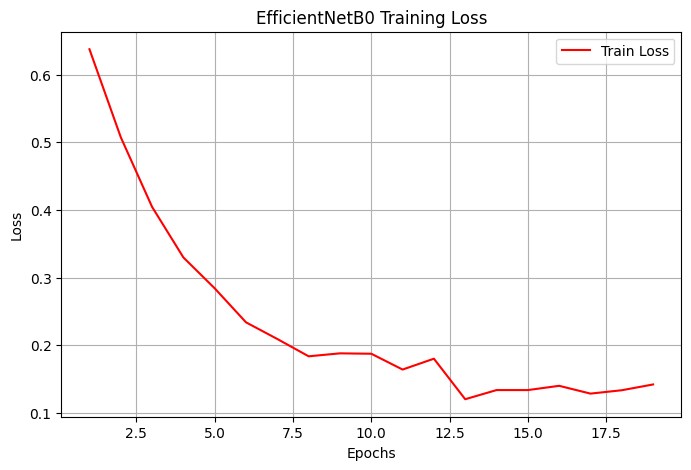

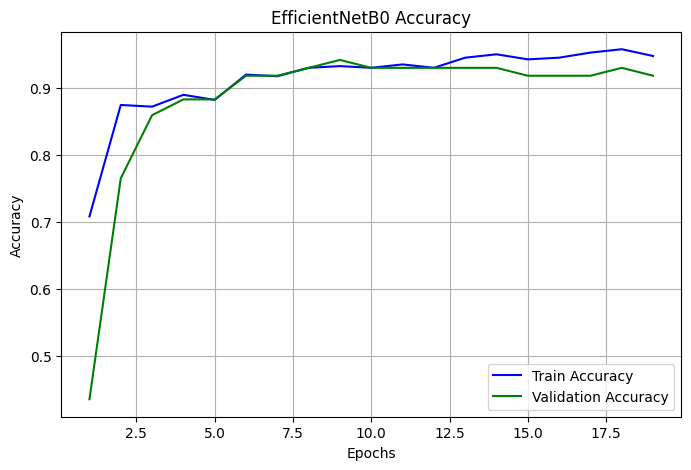

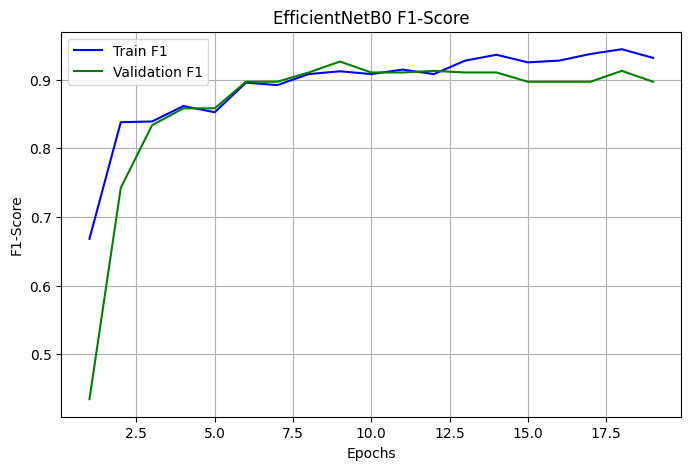

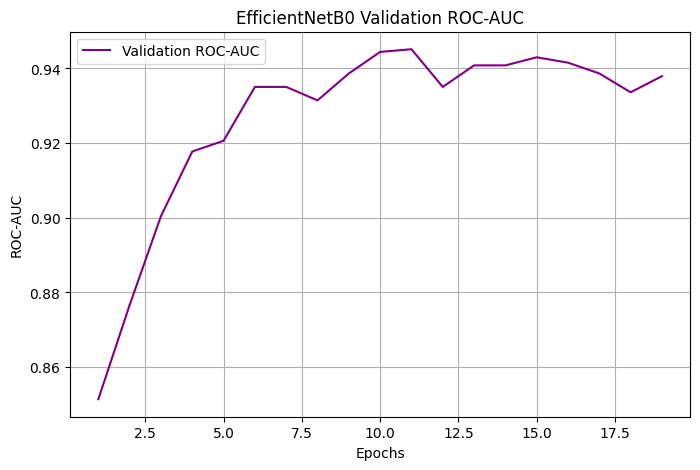

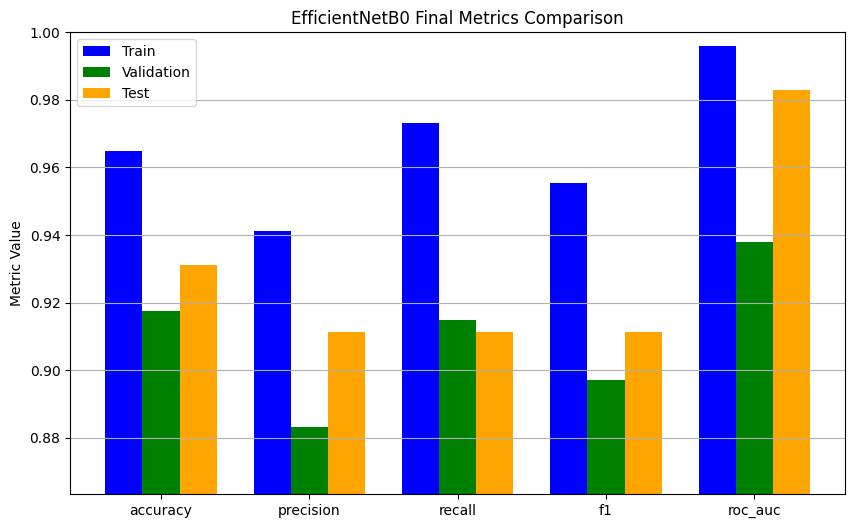

In [20]:
# -----------------------------
# Load JSON file with outputs
# -----------------------------
with open('/kaggle/working/outputs/efficientnet_b0_results_20251107_172132.json', 'r') as f:
    data = json.load(f)

history = data['history']

# Extract metrics
train_loss = history['train_loss']
train_acc = history['train_acc']
train_f1 = history['train_f1']

val_acc = history['val_acc']
val_f1 = history['val_f1']
val_roc_auc = [m['roc_auc'] for m in history['val_metrics']]

epochs = list(range(1, len(train_loss) + 1))

# -----------------------------
# Plot Loss
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, label='Train Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('EfficientNetB0 Training Loss')
plt.grid(True)
plt.legend()
plt.show()
# -----------------------------
# Plot Accuracy
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(epochs, train_acc, label='Train Accuracy', color='blue')
plt.plot(epochs, val_acc, label='Validation Accuracy', color='green')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('EfficientNetB0 Accuracy')
plt.grid(True)
plt.legend()
plt.show()

# -----------------------------
# Plot F1-Score
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(epochs, train_f1, label='Train F1', color='blue')
plt.plot(epochs, val_f1, label='Validation F1', color='green')
plt.xlabel('Epochs')
plt.ylabel('F1-Score')
plt.title('EfficientNetB0 F1-Score')
plt.grid(True)
plt.legend()
plt.show()

# -----------------------------
# Plot ROC-AUC
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(epochs, val_roc_auc, label='Validation ROC-AUC', color='purple')
plt.xlabel('Epochs')
plt.ylabel('ROC-AUC')
plt.title('EfficientNetB0 Validation ROC-AUC')
plt.grid(True)
plt.legend()
plt.show()
# -----------------------------
# Final Metrics Comparison (Train, Validation, Test)
# -----------------------------
metrics_train = data['metrics_train']
metrics_val = data['metrics_val']
metrics_test = data['metrics_test']

metric_names = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

train_values = [metrics_train[m] for m in metric_names]
val_values = [metrics_val[m] for m in metric_names]
test_values = [metrics_test[m] for m in metric_names]

x = np.arange(len(metric_names))  # the label locations
width = 0.25  # width of the bars

plt.figure(figsize=(10,6))
plt.bar(x - width, train_values, width, label='Train', color='blue')
plt.bar(x, val_values, width, label='Validation', color='green')
plt.bar(x + width, test_values, width, label='Test', color='orange')

plt.xticks(x, metric_names)
min_val = min(train_values + val_values + test_values)
plt.ylim(min_val - 0.02, 1.0) 
plt.ylabel('Metric Value')
plt.title('EfficientNetB0 Final Metrics Comparison')
plt.grid(axis='y')
plt.legend()
plt.show()

In [21]:
main("mobilenet_v2")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth



*** Running: mobilenet_v2 ***


100%|██████████| 13.6M/13.6M [00:00<00:00, 115MB/s] 


=== mobilenet_v2 Epoch 1/100 ===


Train loss: 0.4404 acc: 0.8111 f1: 0.7131
Val metrics: acc 0.6706 f1 0.6569 roc_auc 0.8621933621933622
Saved best checkpoint to checkpoints/mobilenet_v2_best.pth

=== mobilenet_v2 Epoch 2/100 ===
Train loss: 0.2758 acc: 0.9043 f1: 0.8738
Val metrics: acc 0.8941 f1 0.8710 roc_auc 0.8795093795093795
Saved best checkpoint to checkpoints/mobilenet_v2_best.pth

=== mobilenet_v2 Epoch 3/100 ===
Train loss: 0.2331 acc: 0.9043 f1: 0.8713
Val metrics: acc 0.9059 f1 0.8839 roc_auc 0.8903318903318902
Saved best checkpoint to checkpoints/mobilenet_v2_best.pth

=== mobilenet_v2 Epoch 4/100 ===
Train loss: 0.2051 acc: 0.9270 f1: 0.9040
Val metrics: acc 0.9176 f1 0.8971 roc_auc 0.9148629148629148
Saved best checkpoint to checkpoints/mobilenet_v2_best.pth

=== mobilenet_v2 Epoch 5/100 ===
Train loss: 0.2042 acc: 0.9194 f1: 0.8951
Val metrics: acc 0.9059 f1 0.8839 roc_auc 0.9170274170274171

=== mobilenet_v2 Epoch 6/100 ===
Train loss: 0.1795 acc: 0.9219 f1: 0.9000
Val metrics: acc 0.9176 f1 0.8942 roc

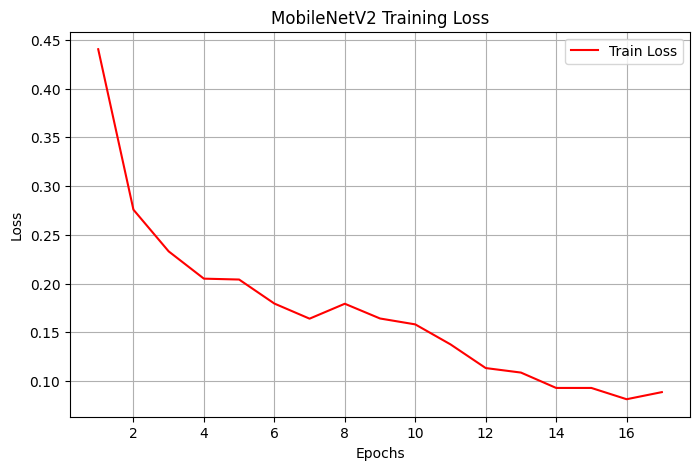

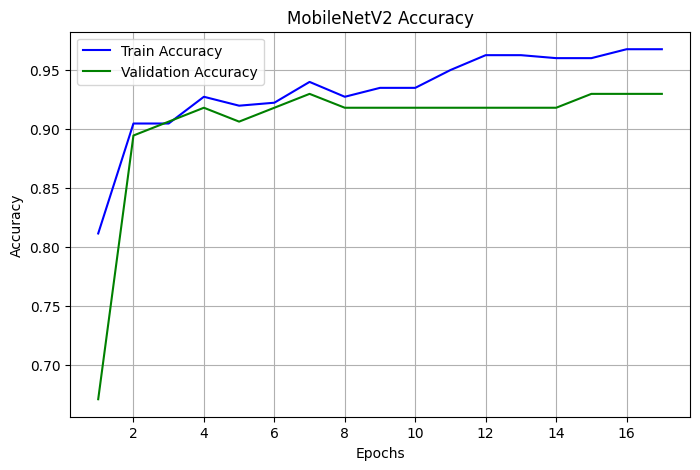

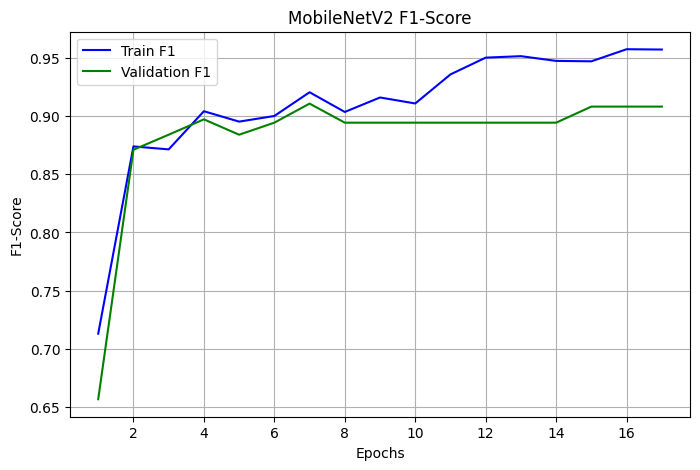

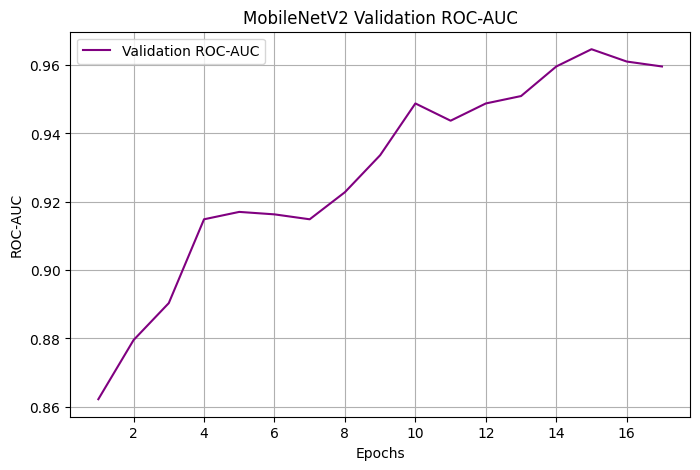

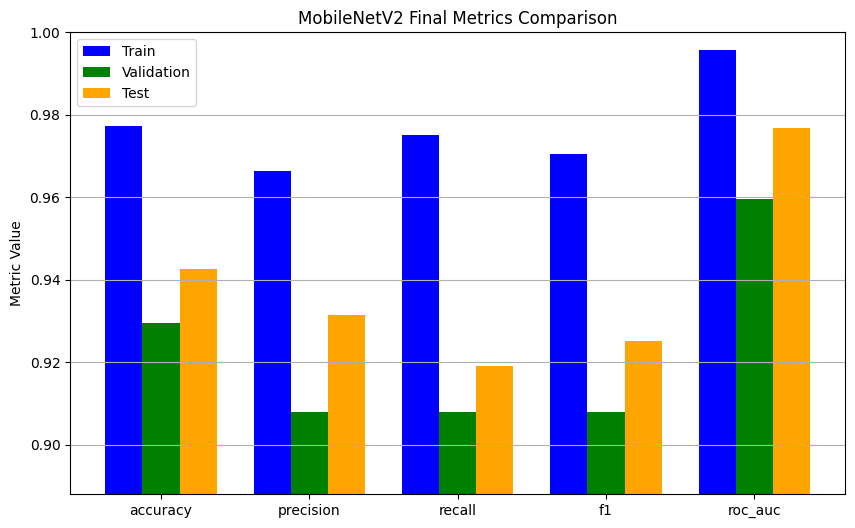

In [22]:
# -----------------------------
# Load JSON file with outputs
# -----------------------------
with open('/kaggle/working/outputs/mobilenet_v2_results_20251107_172806.json', 'r') as f:
    data = json.load(f)

history = data['history']

# Extract metrics
train_loss = history['train_loss']
train_acc = history['train_acc']
train_f1 = history['train_f1']

val_acc = history['val_acc']
val_f1 = history['val_f1']
val_roc_auc = [m['roc_auc'] for m in history['val_metrics']]

epochs = list(range(1, len(train_loss) + 1))

# -----------------------------
# Plot Loss
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, label='Train Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('MobileNetV2 Training Loss')
plt.grid(True)
plt.legend()
plt.show()
# -----------------------------
# Plot Accuracy
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(epochs, train_acc, label='Train Accuracy', color='blue')
plt.plot(epochs, val_acc, label='Validation Accuracy', color='green')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('MobileNetV2 Accuracy')
plt.grid(True)
plt.legend()
plt.show()

# -----------------------------
# Plot F1-Score
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(epochs, train_f1, label='Train F1', color='blue')
plt.plot(epochs, val_f1, label='Validation F1', color='green')
plt.xlabel('Epochs')
plt.ylabel('F1-Score')
plt.title('MobileNetV2 F1-Score')
plt.grid(True)
plt.legend()
plt.show()

# -----------------------------
# Plot ROC-AUC
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(epochs, val_roc_auc, label='Validation ROC-AUC', color='purple')
plt.xlabel('Epochs')
plt.ylabel('ROC-AUC')
plt.title('MobileNetV2 Validation ROC-AUC')
plt.grid(True)
plt.legend()
plt.show()
# -----------------------------
# Final Metrics Comparison (Train, Validation, Test)
# -----------------------------
metrics_train = data['metrics_train']
metrics_val = data['metrics_val']
metrics_test = data['metrics_test']

metric_names = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

train_values = [metrics_train[m] for m in metric_names]
val_values = [metrics_val[m] for m in metric_names]
test_values = [metrics_test[m] for m in metric_names]

x = np.arange(len(metric_names))  # the label locations
width = 0.25  # width of the bars

plt.figure(figsize=(10,6))
plt.bar(x - width, train_values, width, label='Train', color='blue')
plt.bar(x, val_values, width, label='Validation', color='green')
plt.bar(x + width, test_values, width, label='Test', color='orange')

plt.xticks(x, metric_names)
min_val = min(train_values + val_values + test_values)
plt.ylim(min_val - 0.02, 1.0) 
plt.ylabel('Metric Value')
plt.title('MobileNetV2 Final Metrics Comparison')
plt.grid(axis='y')
plt.legend()
plt.show()

In [27]:
main("densenet121")


*** Running: densenet121 ***

=== densenet121 Epoch 1/100 ===
Train loss: 0.6833 acc: 0.6045 f1: 0.5959
Val metrics: acc 0.8235 f1 0.7984 roc_auc 0.8939393939393938
Saved best checkpoint to checkpoints/densenet121_best.pth

=== densenet121 Epoch 2/100 ===
Train loss: 0.3066 acc: 0.8942 f1: 0.8606
Val metrics: acc 0.9176 f1 0.8971 roc_auc 0.9069264069264069
Saved best checkpoint to checkpoints/densenet121_best.pth

=== densenet121 Epoch 3/100 ===
Train loss: 0.2120 acc: 0.9244 f1: 0.8997
Val metrics: acc 0.9294 f1 0.9106 roc_auc 0.904040404040404
Saved best checkpoint to checkpoints/densenet121_best.pth

=== densenet121 Epoch 4/100 ===
Train loss: 0.2100 acc: 0.9144 f1: 0.8848
Val metrics: acc 0.9176 f1 0.8942 roc_auc 0.9227994227994227

=== densenet121 Epoch 5/100 ===
Train loss: 0.1801 acc: 0.9446 f1: 0.9260
Val metrics: acc 0.9176 f1 0.8910 roc_auc 0.9357864357864358

=== densenet121 Epoch 6/100 ===
Train loss: 0.1673 acc: 0.9395 f1: 0.9208
Val metrics: acc 0.9176 f1 0.8942 roc_auc 

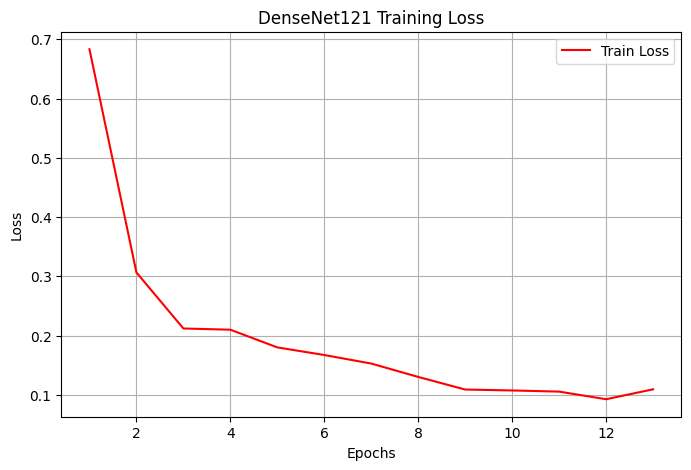

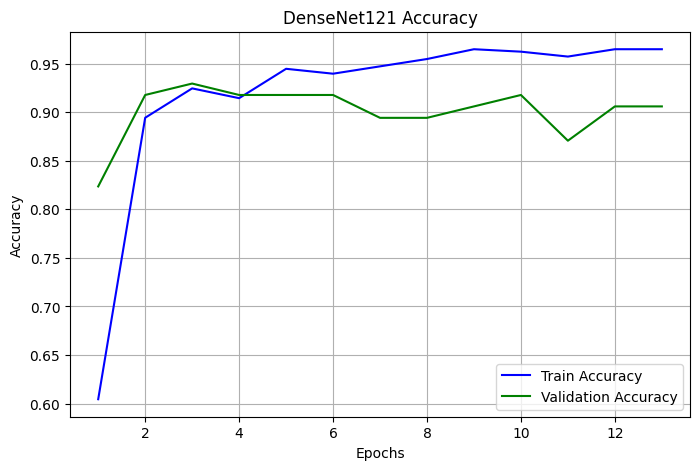

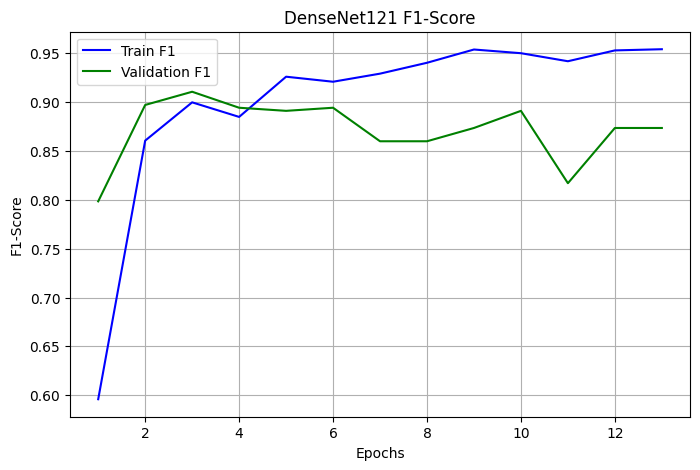

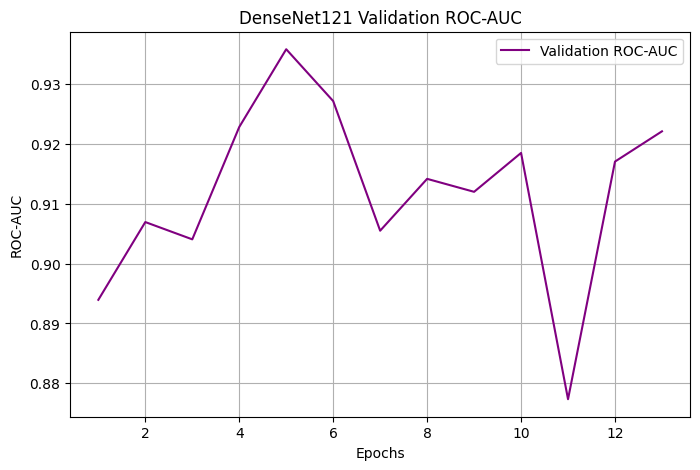

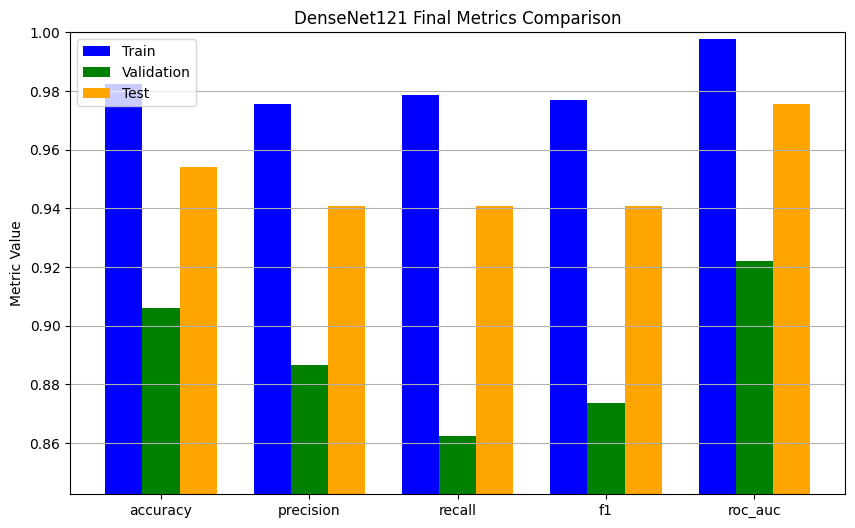

In [28]:
# -----------------------------
# Load JSON file with outputs
# -----------------------------
with open('/kaggle/working/outputs/densenet121_results_20251107_173851.json', 'r') as f:
    data = json.load(f)

history = data['history']

# Extract metrics
train_loss = history['train_loss']
train_acc = history['train_acc']
train_f1 = history['train_f1']

val_acc = history['val_acc']
val_f1 = history['val_f1']
val_roc_auc = [m['roc_auc'] for m in history['val_metrics']]

epochs = list(range(1, len(train_loss) + 1))

# -----------------------------
# Plot Loss
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, label='Train Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('DenseNet121 Training Loss')
plt.grid(True)
plt.legend()
plt.show()
# -----------------------------
# Plot Accuracy
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(epochs, train_acc, label='Train Accuracy', color='blue')
plt.plot(epochs, val_acc, label='Validation Accuracy', color='green')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('DenseNet121 Accuracy')
plt.grid(True)
plt.legend()
plt.show()

# -----------------------------
# Plot F1-Score
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(epochs, train_f1, label='Train F1', color='blue')
plt.plot(epochs, val_f1, label='Validation F1', color='green')
plt.xlabel('Epochs')
plt.ylabel('F1-Score')
plt.title('DenseNet121 F1-Score')
plt.grid(True)
plt.legend()
plt.show()

# -----------------------------
# Plot ROC-AUC
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(epochs, val_roc_auc, label='Validation ROC-AUC', color='purple')
plt.xlabel('Epochs')
plt.ylabel('ROC-AUC')
plt.title('DenseNet121 Validation ROC-AUC')
plt.grid(True)
plt.legend()
plt.show()
# -----------------------------
# Final Metrics Comparison (Train, Validation, Test)
# -----------------------------
metrics_train = data['metrics_train']
metrics_val = data['metrics_val']
metrics_test = data['metrics_test']

metric_names = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

train_values = [metrics_train[m] for m in metric_names]
val_values = [metrics_val[m] for m in metric_names]
test_values = [metrics_test[m] for m in metric_names]

x = np.arange(len(metric_names))  # the label locations
width = 0.25  # width of the bars

plt.figure(figsize=(10,6))
plt.bar(x - width, train_values, width, label='Train', color='blue')
plt.bar(x, val_values, width, label='Validation', color='green')
plt.bar(x + width, test_values, width, label='Test', color='orange')

plt.xticks(x, metric_names)
min_val = min(train_values + val_values + test_values)
plt.ylim(min_val - 0.02, 1.0) 
plt.ylabel('Metric Value')
plt.title('DenseNet121 Final Metrics Comparison')
plt.grid(axis='y')
plt.legend()
plt.show()

In [30]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from PIL import Image
import numpy as np
import cv2
import os
from collections import OrderedDict

# -----------------------------
# Grad-CAM++ Class
# -----------------------------
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.model.eval()
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        target_layer.register_forward_hook(lambda m,i,o: setattr(self, 'activations', o.detach()))
        target_layer.register_backward_hook(lambda m,gi,go: setattr(self, 'gradients', go[0].detach()))

    def __call__(self, x, class_idx=None):
        self.model.zero_grad()
        out = self.model(x)
        if class_idx is None:
            class_idx = out.argmax(dim=1).item()
        score = out[:, class_idx]
        score.backward(retain_graph=True)

        grads = self.gradients[0]   # C x H x W
        acts = self.activations[0]  # C x H x W

        # Grad-CAM++ weights calculation
        alpha_num = grads.pow(2)
        alpha_denom = 2*grads.pow(2) + (acts * grads.pow(3)).sum(dim=(1,2), keepdim=True)
        alpha = alpha_num / (alpha_denom + 1e-8)
        weights = (alpha * torch.relu(grads)).sum(dim=(1,2))

        cam = (weights[:, None, None] * acts).sum(dim=0).cpu().numpy()
        cam = np.maximum(cam, 0)
        cam = cam - cam.min()
        if cam.max() != 0:
            cam = cam / cam.max()
        cam = np.uint8(255 * cam)
        return cam

def save_gradcam_overlay(pil_img, cam, out_path, alpha=0.4):
    orig_size = pil_img.size  # (width, height)
    cam_resized = cv2.resize(cam, orig_size, interpolation=cv2.INTER_LINEAR)

    heatmap = cv2.applyColorMap(cam_resized, cv2.COLORMAP_JET)

    orig = np.array(pil_img.convert('RGB'))
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(heatmap, alpha, orig, 1 - alpha, 0)
    Image.fromarray(overlay).save(out_path)

def preprocess_image(image_path, device):
    img = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406],
                             std=[0.229,0.224,0.225])
    ])
    tensor = transform(img).unsqueeze(0).to(device)
    return img, tensor

def find_target_layer(model):
    if hasattr(model, "layer4"):
        return model.layer4[-1]
    if hasattr(model, "features"):
        return model.features[-1]
    last = None
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            last = m
    return last

def load_model_ignore_mismatch(model_name, checkpoint_path, num_classes=2, device='cpu'):
    if model_name == "resnet18":
        model = models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name == "resnet50":
        model = models.resnet50(weights=None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name == "vgg16":
        model = models.vgg16(weights=None)
        model.classifier[6] = nn.Linear(4096, num_classes)

    elif model_name == "mobilenet_v2":
        model = models.mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(model.last_channel, num_classes)

    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    elif model_name == "densenet121":
        model = models.densenet121(weights=None)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
        
    else:
        raise ValueError("Unsupported model")

    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

    if 'model_state' in checkpoint:
        state_dict = checkpoint['model_state']
    elif 'state_dict' in checkpoint:
        state_dict = checkpoint['state_dict']
    else:
        state_dict = checkpoint

    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        name = k.replace('module.', '')
        new_state_dict[name] = v

    model.load_state_dict(new_state_dict, strict=False)
    model.to(device).eval()
    target_layer = find_target_layer(model)
    return model, target_layer

# -----------------------------
# Generate Grad-CAM++ on the same image for all models
# -----------------------------
def generate_gradcam_for_image(image_path, checkpoint_paths, output_dir="/kaggle/working/gradcam_outputs", device='cpu'):
    os.makedirs(output_dir, exist_ok=True)
    pil_img, input_tensor = preprocess_image(image_path, device)
    img_name = os.path.basename(image_path)

    for model_name, ckpt_path in checkpoint_paths.items():
        print(f"\n➡ Generating Grad-CAM++ for {model_name} on {img_name}...")
        model, target_layer = load_model_ignore_mismatch(model_name, ckpt_path, device=device)
        gradcam = GradCAM(model, target_layer)
        model_out_dir = os.path.join(output_dir, model_name)
        os.makedirs(model_out_dir, exist_ok=True)

        cam = gradcam(input_tensor)
        out_path = os.path.join(model_out_dir, f"gradcam_{img_name}")
        save_gradcam_overlay(pil_img, cam, out_path)
        print(f"Saved Grad-CAM++ for {model_name} → {out_path}")

# -----------------------------
# Main entry point
# -----------------------------
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    image_path = "/kaggle/input/sickle-cell-disease-dataset/Positive/Unlabelled/109.jpg"

    checkpoint_paths = {
        "resnet50": "/kaggle/working/outputs/resnet50_final.pth",
        "vgg16": "/kaggle/working/outputs/vgg16_final.pth",
        "mobilenet_v2": "/kaggle/working/outputs/mobilenet_v2_final.pth",
        "efficientnet_b0": "/kaggle/working/outputs/efficientnet_b0_final.pth",
        "densenet121": "/kaggle/working/outputs/densenet121_final.pth"
    }

    generate_gradcam_for_image(image_path, checkpoint_paths, output_dir="/kaggle/working/gradcam_outputs", device=device)


➡ Generating Grad-CAM++ for resnet50 on 109.jpg...


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Saved Grad-CAM++ for resnet50 → /kaggle/working/gradcam_outputs/resnet50/gradcam_109.jpg

➡ Generating Grad-CAM++ for vgg16 on 109.jpg...
Saved Grad-CAM++ for vgg16 → /kaggle/working/gradcam_outputs/vgg16/gradcam_109.jpg

➡ Generating Grad-CAM++ for mobilenet_v2 on 109.jpg...
Saved Grad-CAM++ for mobilenet_v2 → /kaggle/working/gradcam_outputs/mobilenet_v2/gradcam_109.jpg

➡ Generating Grad-CAM++ for efficientnet_b0 on 109.jpg...
Saved Grad-CAM++ for efficientnet_b0 → /kaggle/working/gradcam_outputs/efficientnet_b0/gradcam_109.jpg

➡ Generating Grad-CAM++ for densenet121 on 109.jpg...
Saved Grad-CAM++ for densenet121 → /kaggle/working/gradcam_outputs/densenet121/gradcam_109.jpg


In [31]:
!pip install captum

import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from PIL import Image
import numpy as np
import cv2
import os
from collections import OrderedDict
import matplotlib.pyplot as plt
import gc

from captum.attr import IntegratedGradients, GuidedBackprop, Occlusion, NoiseTunnel

# Set memory management
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

# Clear cache
torch.cuda.empty_cache()
gc.collect()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Total memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.6 MB/s eta 0:00:00a 0:00:01
Using device: cuda
GPU: Tesla T4
Total memory: 15.83 GB


In [32]:
# -----------------------------
# Utility Functions
# -----------------------------
def preprocess_image(image_path, device):
    """Load and preprocess image for model input"""
    img = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])
    tensor = transform(img).unsqueeze(0).to(device)
    return img, tensor

def find_target_layer(model):
    """Find the last convolutional layer for Grad-CAM"""
    if hasattr(model, "layer4"):
        return model.layer4[-1]
    if hasattr(model, "features"):
        return model.features[-1]
    last = None
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            last = m
    return last

def load_model_ignore_mismatch(model_name, checkpoint_path, num_classes=2, device='cpu'):
    """Load model architecture and checkpoint with mismatch handling"""
    if model_name == "resnet18":
        model = models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name == "resnet50":
        model = models.resnet50(weights=None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name == "vgg16":
        model = models.vgg16(weights=None)
        model.classifier[6] = nn.Linear(4096, num_classes)

    elif model_name == "mobilenet_v2":
        model = models.mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(model.last_channel, num_classes)

    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    elif model_name == "densenet121":
        model = models.densenet121(weights=None)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
        
    else:
        raise ValueError("Unsupported model")

    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

    if 'model_state' in checkpoint:
        state_dict = checkpoint['model_state']
    elif 'state_dict' in checkpoint:
        state_dict = checkpoint['state_dict']
    else:
        state_dict = checkpoint

    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        name = k.replace('module.', '')
        new_state_dict[name] = v

    model.load_state_dict(new_state_dict, strict=False)
    model.to(device).eval()
    target_layer = find_target_layer(model)
    return model, target_layer

def visualize_attribution(attribution):
    """Convert attribution to normalized heatmap"""
    if attribution.ndim == 3 and attribution.shape[0] == 3:
        attribution = np.transpose(attribution, (1, 2, 0))
    
    if attribution.ndim == 3:
        attribution = np.mean(attribution, axis=2)
    
    attribution = attribution - attribution.min()
    if attribution.max() != 0:
        attribution = attribution / attribution.max()
    
    return attribution

def save_overlay_image(pil_img, attribution, output_path, alpha=0.4):
    """Save attribution as heatmap overlay on original image"""
    # Visualize attribution
    viz_attr = visualize_attribution(attribution)
    
    # Resize to original image size
    orig_size = pil_img.size
    viz_attr_resized = cv2.resize(viz_attr, orig_size, interpolation=cv2.INTER_LINEAR)
    
    # Create heatmap
    heatmap = cv2.applyColorMap(np.uint8(255 * viz_attr_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    
    # Overlay on original
    orig = np.array(pil_img.convert('RGB'))
    overlay = cv2.addWeighted(heatmap, alpha, orig, 1 - alpha, 0)
    
    # Save
    Image.fromarray(overlay).save(output_path)
    print(f"   ✓ Saved: {output_path}")

print("✓ All utility functions loaded!")

✓ All utility functions loaded!


In [39]:
# -----------------------------
# XAI Processing Functions
# -----------------------------
def process_gradcam(model_name, checkpoint_path, image_path, output_dir, device):
    """Process Grad-CAM++ for one model"""
    print(f"   Processing {model_name}...")
    
    pil_img, input_tensor = preprocess_image(image_path, device)
    img_name = os.path.splitext(os.path.basename(image_path))[0]
    
    model, target_layer = load_model_ignore_mismatch(model_name, checkpoint_path, device=device)
    
    gradcam = GradCAMPlusPlus(model, target_layer)
    cam, pred_class = gradcam(input_tensor)
    
    output_path = os.path.join(output_dir, f"{model_name}_gradcam_{img_name}.png")
    save_overlay_image(pil_img, cam, output_path)
    
    gradcam.remove_hooks()
    del model, gradcam, input_tensor, cam
    torch.cuda.empty_cache()
    gc.collect()

def process_integrated_gradients(model_name, checkpoint_path, image_path, output_dir, device):
    """Process Integrated Gradients for one model"""
    print(f"  Processing {model_name}...")
    
    pil_img, input_tensor = preprocess_image(image_path, device)
    img_name = os.path.splitext(os.path.basename(image_path))[0]
    
    model, _ = load_model_ignore_mismatch(model_name, checkpoint_path, device=device)
    
    ig = IntegratedGradients(model)
    with torch.no_grad():
        pred_class = model(input_tensor).argmax(dim=1).item()
    
    baseline = torch.zeros_like(input_tensor)
    attributions = ig.attribute(input_tensor, baseline, target=pred_class, n_steps=25)
    attr_np = attributions.squeeze().cpu().detach().numpy()
    
    output_path = os.path.join(output_dir, f"{model_name}_integratedgradients_{img_name}.png")
    save_overlay_image(pil_img, attr_np, output_path)
    
    del model, ig, attributions, input_tensor, baseline, attr_np
    torch.cuda.empty_cache()
    gc.collect()

def process_guided_backprop(model_name, checkpoint_path, image_path, output_dir, device):
    """Process Guided Backpropagation for one model"""
    print(f"  Processing {model_name}...")
    
    pil_img, input_tensor = preprocess_image(image_path, device)
    img_name = os.path.splitext(os.path.basename(image_path))[0]
    
    model, _ = load_model_ignore_mismatch(model_name, checkpoint_path, device=device)
    
    gbp = GuidedBackprop(model)
    with torch.no_grad():
        pred_class = model(input_tensor).argmax(dim=1).item()
    
    attributions = gbp.attribute(input_tensor, target=pred_class)
    attr_np = attributions.squeeze().cpu().detach().numpy()
    
    output_path = os.path.join(output_dir, f"{model_name}_guidedbackprop_{img_name}.png")
    save_overlay_image(pil_img, attr_np, output_path)
    
    del model, gbp, attributions, input_tensor, attr_np
    torch.cuda.empty_cache()
    gc.collect()

def process_occlusion(model_name, checkpoint_path, image_path, output_dir, device):
    """Process Occlusion Sensitivity for one model"""
    print(f"   Processing {model_name}...")
    
    pil_img, input_tensor = preprocess_image(image_path, device)
    img_name = os.path.splitext(os.path.basename(image_path))[0]
    
    model, _ = load_model_ignore_mismatch(model_name, checkpoint_path, device=device)
    
    occlusion = Occlusion(model)
    with torch.no_grad():
        pred_class = model(input_tensor).argmax(dim=1).item()
    
    attributions = occlusion.attribute(
        input_tensor,
        target=pred_class,
        strides=(3, 8, 8),
        sliding_window_shapes=(3, 15, 15),
        baselines=0
    )
    attr_np = attributions.squeeze().cpu().detach().numpy()
    
    output_path = os.path.join(output_dir, f"{model_name}_occlusion_{img_name}.png")
    save_overlay_image(pil_img, attr_np, output_path)
    
    del model, occlusion, attributions, input_tensor, attr_np
    torch.cuda.empty_cache()
    gc.collect()

def process_smoothgrad(model_name, checkpoint_path, image_path, output_dir, device):
    """Process SmoothGrad for one model"""
    print(f" Processing {model_name}...")
    
    pil_img, input_tensor = preprocess_image(image_path, device)
    img_name = os.path.splitext(os.path.basename(image_path))[0]
    
    model, _ = load_model_ignore_mismatch(model_name, checkpoint_path, device=device)
    
    ig = IntegratedGradients(model)
    nt = NoiseTunnel(ig)
    
    with torch.no_grad():
        pred_class = model(input_tensor).argmax(dim=1).item()
    
    baseline = torch.zeros_like(input_tensor)
    attributions = nt.attribute(
        input_tensor,
        nt_type='smoothgrad',
        nt_samples=25,
        stdevs=0.15,
        baselines=baseline,
        target=pred_class
    )
    attr_np = attributions.squeeze().cpu().detach().numpy()
    
    output_path = os.path.join(output_dir, f"{model_name}_smoothgrad_{img_name}.png")
    save_overlay_image(pil_img, attr_np, output_path)
    
    del model, ig, nt, attributions, input_tensor, baseline, attr_np
    torch.cuda.empty_cache()
    gc.collect()

print("✓ All XAI processing functions loaded!")

✓ All XAI processing functions loaded!


In [36]:
# Image path
image_path = "/kaggle/input/sickle-cell-disease-dataset/Positive/Unlabelled/109.jpg"

# Output directory
output_dir = "/kaggle/working/xai_outputs"
os.makedirs(output_dir, exist_ok=True)

# Model checkpoints
checkpoint_paths = {
    "resnet50": "/kaggle/working/outputs/resnet50_final.pth",
        "vgg16": "/kaggle/working/outputs/vgg16_final.pth",
        "mobilenet_v2": "/kaggle/working/outputs/mobilenet_v2_final.pth",
        "efficientnet_b0": "/kaggle/working/outputs/efficientnet_b0_final.pth",
        "densenet121": "/kaggle/working/outputs/densenet121_final.pth"
}

print("✓ Configuration complete!")
print(f"Image: {image_path}")
print(f"Output: {output_dir}")
print(f"Models: {list(checkpoint_paths.keys())}")

✓ Configuration complete!
Image: /kaggle/input/sickle-cell-disease-dataset/Positive/Unlabelled/109.jpg
Output: /kaggle/working/xai_outputs
Models: ['resnet50', 'vgg16', 'mobilenet_v2', 'efficientnet_b0', 'densenet121']


In [37]:
print("\n" + "="*70)
print("Guided Backpropagation")
print("="*70)

gbp_dir = os.path.join(output_dir, "guided_backprop")
os.makedirs(gbp_dir, exist_ok=True)

for model_name, ckpt_path in checkpoint_paths.items():
    torch.cuda.empty_cache()
    gc.collect()
    process_guided_backprop(model_name, ckpt_path, image_path, gbp_dir, device)

print("Guided Backpropagation complete for all models!\n")


Guided Backpropagation
   📊 Processing resnet50...


/usr/local/lib/python3.11/dist-packages/captum/attr/_core/guided_backprop_deconvnet.py:63: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
/usr/local/lib/python3.11/dist-packages/captum/attr/_core/guided_backprop_deconvnet.py:66: UserWarning: Setting backward hooks on ReLU activations.The hooks will be removed after the attribution is finished
  warnings.warn(


   ✓ Saved: /kaggle/working/xai_outputs/guided_backprop/resnet50_guidedbackprop_109.png
   📊 Processing vgg16...
   ✓ Saved: /kaggle/working/xai_outputs/guided_backprop/vgg16_guidedbackprop_109.png
   📊 Processing mobilenet_v2...
   ✓ Saved: /kaggle/working/xai_outputs/guided_backprop/mobilenet_v2_guidedbackprop_109.png
   📊 Processing efficientnet_b0...
   ✓ Saved: /kaggle/working/xai_outputs/guided_backprop/efficientnet_b0_guidedbackprop_109.png
   📊 Processing densenet121...
   ✓ Saved: /kaggle/working/xai_outputs/guided_backprop/densenet121_guidedbackprop_109.png
Guided Backpropagation complete for all models!



In [40]:
print("\n" + "="*70)
print("Integrated Gradients")
print("="*70)

ig_dir = os.path.join(output_dir, "integrated_gradients")
os.makedirs(ig_dir, exist_ok=True)

for model_name, ckpt_path in checkpoint_paths.items():
    torch.cuda.empty_cache()
    gc.collect()
    process_integrated_gradients(model_name, ckpt_path, image_path, ig_dir, device)

print("Integrated Gradients complete for all models!\n")


Integrated Gradients
  Processing resnet50...
   ✓ Saved: /kaggle/working/xai_outputs/integrated_gradients/resnet50_integratedgradients_109.png
  Processing vgg16...
   ✓ Saved: /kaggle/working/xai_outputs/integrated_gradients/vgg16_integratedgradients_109.png
  Processing mobilenet_v2...
   ✓ Saved: /kaggle/working/xai_outputs/integrated_gradients/mobilenet_v2_integratedgradients_109.png
  Processing efficientnet_b0...
   ✓ Saved: /kaggle/working/xai_outputs/integrated_gradients/efficientnet_b0_integratedgradients_109.png
  Processing densenet121...
   ✓ Saved: /kaggle/working/xai_outputs/integrated_gradients/densenet121_integratedgradients_109.png
Integrated Gradients complete for all models!



In [41]:
print("\n" + "="*70)
print("Occlusion Sensitivity")
print("="*70)

occ_dir = os.path.join(output_dir, "occlusion")
os.makedirs(occ_dir, exist_ok=True)

for model_name, ckpt_path in checkpoint_paths.items():
    torch.cuda.empty_cache()
    gc.collect()
    process_occlusion(model_name, ckpt_path, image_path, occ_dir, device)

print("Occlusion Sensitivity complete for all models!\n")


Occlusion Sensitivity
   Processing resnet50...
   ✓ Saved: /kaggle/working/xai_outputs/occlusion/resnet50_occlusion_109.png
   Processing vgg16...
   ✓ Saved: /kaggle/working/xai_outputs/occlusion/vgg16_occlusion_109.png
   Processing mobilenet_v2...
   ✓ Saved: /kaggle/working/xai_outputs/occlusion/mobilenet_v2_occlusion_109.png
   Processing efficientnet_b0...
   ✓ Saved: /kaggle/working/xai_outputs/occlusion/efficientnet_b0_occlusion_109.png
   Processing densenet121...
   ✓ Saved: /kaggle/working/xai_outputs/occlusion/densenet121_occlusion_109.png
Occlusion Sensitivity complete for all models!

